# Analyze imgep dataset
## Explain what are bus and ddr bandwidths
* DDR bandwidth: For a given time cycle window, number of instructions that are transmitted from the DDR controller to the DDR main memory. Method sim070726.Var.log_ddr_command implements this metric
* BUS bandwidth: For a given time cycle window, number of instructions that are transmitted from the Interconnect to the DDR controller.
Remark: One can track bandwidth for type of instruction, that is write or read

## Load datasets

In [1]:
import pickle
import numpy  as np
from exploration.load_file import load
from diversity.diversty import Diversity
import matplotlib.pyplot as plt
from sklearn.cluster import HDBSCAN

In [2]:
#Load data
folder = "results"
N = 100000
k=1
print_freq = 1000
name_imgep = f'{folder}/imgep_bandwidth_N_{N}_k_{k}'
name_random = f'{folder}/random_bandwidth_expl_N_{N}'
content_imgep = load(name_imgep)
content_imgep_tab = content_imgep['numpy_view']
content_random = load(name_random)
content_random_tab = content_random['numpy_view']
dim_out = 18
#Compute diversity
##################################
min_tab = np.zeros((dim_out,))
max_tab = np.ones((dim_out,))*10



results/imgep_bandwidth_N_100000_k_1_1.pkl
results/random_bandwidth_expl_N_100000_2.pkl


In [3]:
diversity_imgep_list = [100* Diversity(min_tab = min_tab,max_tab = max_tab,num_bins = num_bins)(content_imgep_tab[:])/(num_bins**dim_out) for num_bins in range(2,10)]
diversity_random_list = [100*Diversity(min_tab = min_tab,max_tab = max_tab,num_bins = num_bins)(content_random_tab[:])/(num_bins**dim_out) for num_bins in range(2,10)]

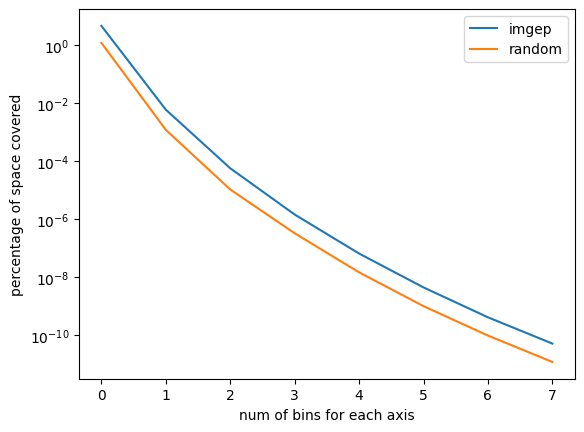

In [4]:
plt.semilogy(diversity_imgep_list,label='imgep')
plt.semilogy(diversity_random_list,label='random')
plt.ylabel('percentage of space covered')
plt.xlabel('num of bins for each axis')
plt.legend()

In [5]:
step = 1000
diversity_imgep_list = [100* Diversity(min_tab = min_tab,max_tab = max_tab,num_bins = 10)(content_imgep_tab[:step]) for step in range(step,N+1,step)]
diversity_random_list = [100*Diversity(min_tab = min_tab,max_tab = max_tab,num_bins = 10)(content_random_tab[:step]) for step in range(step,N+1,step)]

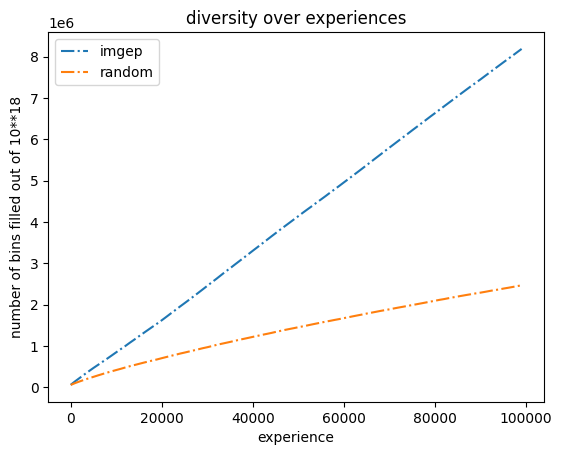

In [6]:
#print(f'diversity imgep {diversity_(content_imgep_tab)}/10**{dim_out}')
#print(f'diversity random {diversity_(content_random_tab)}/10**{dim_out}')
plt.figure()
plt.plot(range(0,N,print_freq),diversity_imgep_list,'-.',label="imgep")
plt.plot(range(0,N,print_freq),diversity_random_list,'-.',label="random")
plt.legend()
plt.title('diversity over experiences')
plt.xlabel('experience')
plt.ylabel(f'number of bins filled out of 10**{dim_out}')
plt.show()

In [8]:
content_imgep['memory_observation'].keys()

dict_keys(['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff', 'bus_bandwidth_core_0_iso', 'bus_bandwidth_core_0_core1', 'ddr_bandwidth_core_0_iso', 'ddr_bandwidth_core_0_core1', 'time_core0_iso', 'time_core0_core1'])

### Imgep finds more various points than random. One would like to identify potential clusters in the dataset. For each time window, we focus on a 3D dimensional space, as we select variables that are different between isolation and parallel execution.
### Although no cluster is naturally appearing, one will employ (SVD,HDBSAN), (UMAP,HDBSCAN) and Kmeans to support this claim.

# One will color the following plots with the obtain clusters for constructive comparison between the methods

In [3]:
combinaisons = lambda dimension: [(i,j) for j in range(1,dimension) for i in range(j)] 

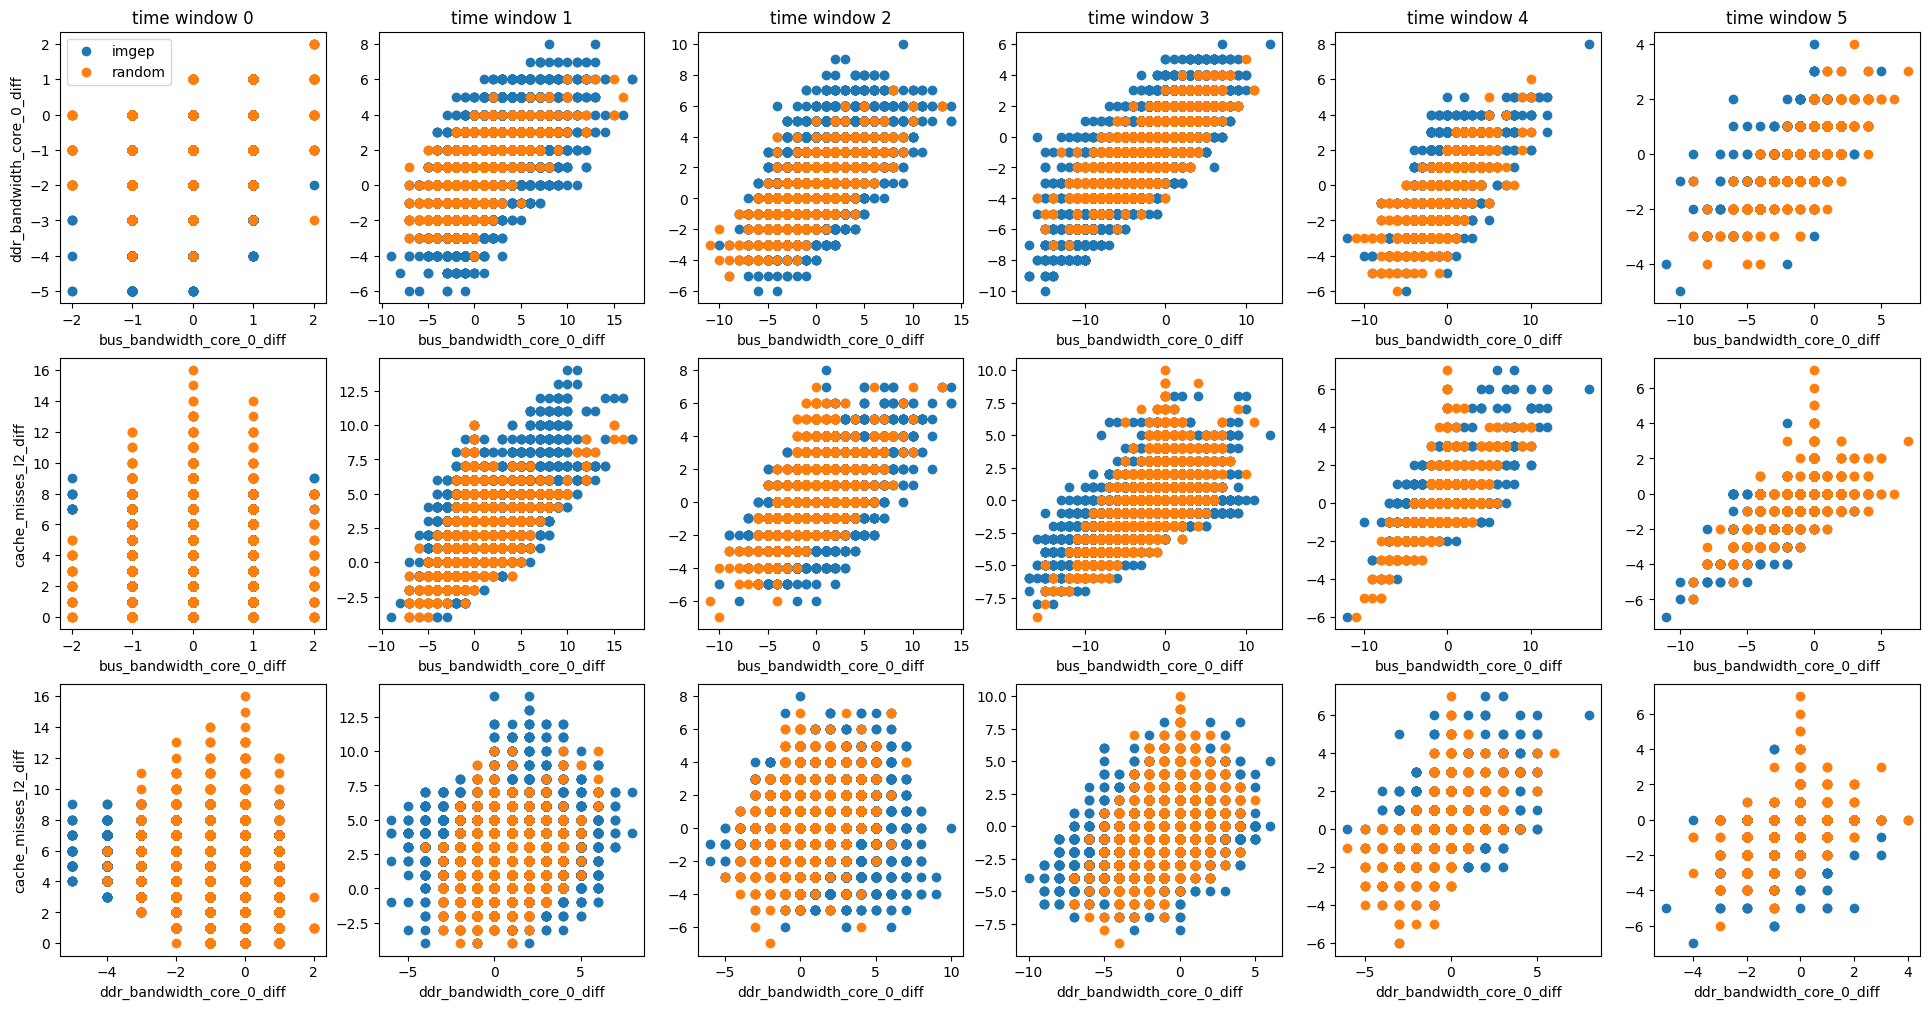

In [4]:
combins = combinaisons(3)
fig,axs = plt.subplots(len(combins),6,figsize=(24,12))
list_feature = ['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff']
for paire,(i,j) in enumerate(combins):
    for time in range(0,6):
        axs[paire,time].scatter(np.array(content_imgep['memory_observation'][list_feature[i]])[:,time],np.array(content_imgep['memory_observation'][list_feature[j]])[:,time],label='imgep')
        axs[paire,time].scatter(np.array(content_random['memory_observation'][list_feature[i]])[:,time],np.array(content_random['memory_observation'][list_feature[j]])[:,time],label='random')
        axs[paire,time].set_xlabel(list_feature[i])
        if paire==0:
            axs[0,time].set_title(f'time window {time}')
    axs[paire,0].set_ylabel(list_feature[j])
axs[0,0].legend()

# Attempt to identify clusters with SVD

### Assuming there is a latent representation of each time stamp, for each time window t, we consider a population where individuals are outputs of experiments. As a result, eigein values are all non-neglectable and no cluster appears on the projected data plots, as no seperation is visible.

In [72]:
feature_list = ['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff']

In [73]:
content_imgep['memory_observation']
content_array_time  = np.array([[[content_imgep['memory_observation'][feature][n][t] for feature in feature_list] for t in range(6)] for n in range(N)])

In [74]:
norm_mean_std = lambda data: (data - data.mean(axis=0))/data.std(axis=0)

sigma diagonal for t=0 [390.89193035 316.3091105  217.14521732]
sigma diagonal for t=1 [407.16444827 324.9983305  169.09523126]
sigma diagonal for t=2 [424.84492758 312.62298045 147.55900382]
sigma diagonal for t=3 [470.64915779 251.31752822 123.80981494]
sigma diagonal for t=4 [427.42593386 299.1904373  166.70978762]
sigma diagonal for t=5 [444.56765457 301.34009705 107.48835482]


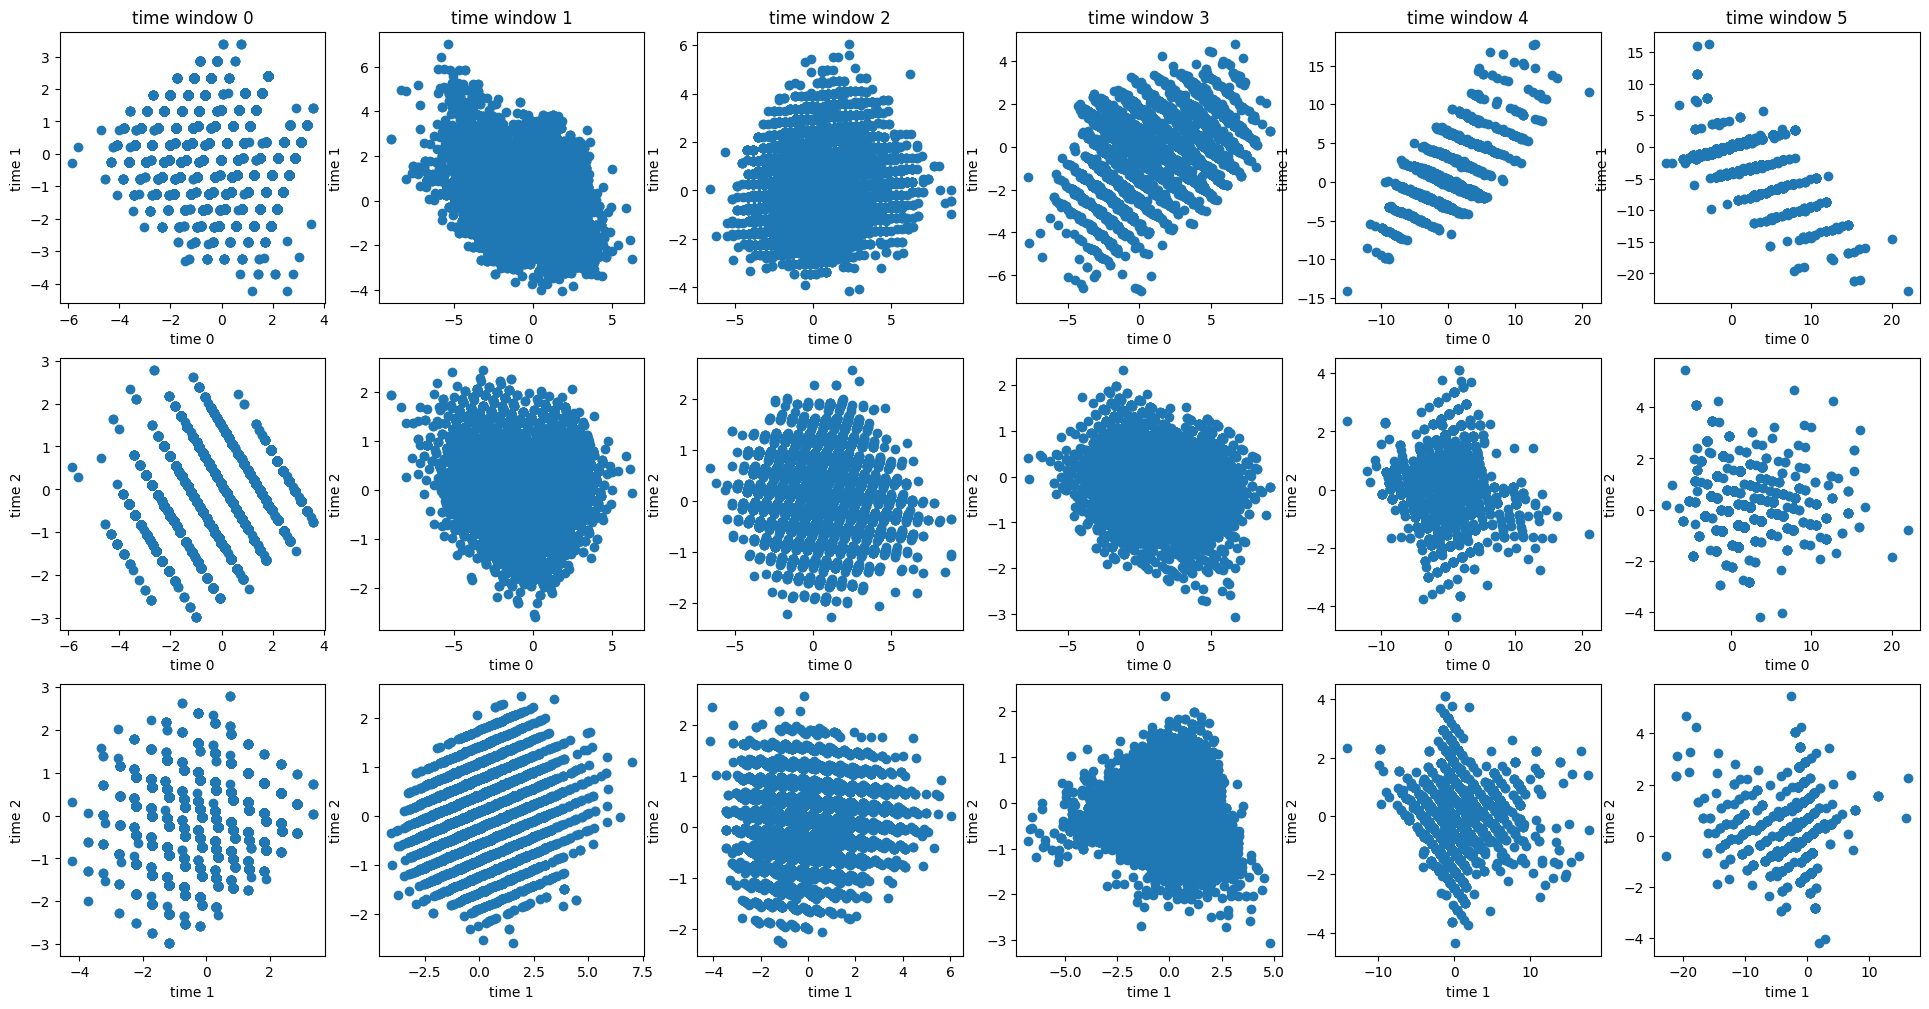

In [75]:
coords = combinaisons(3)
fig,axs = plt.subplots(len(coords),6,figsize=(24,12))
for t in range(6):
    X = content_array_time[:,t,:]
    X = norm_mean_std(X)
    U,Sig,Vt = np.linalg.svd(X,full_matrices=False)
    proj = U*Sig
    print(f'sigma diagonal for t={t}',Sig)
    proj[0]
    for c,(i,j) in enumerate(coords[:]):
        axs[c,t].scatter(proj[:,i],proj[:,j])    
        axs[c,t].set_xlabel(f'time {i}')
        axs[c,t].set_ylabel(f'time {j}')
    axs[0,t].set_title(f'time window {t}')
    #axs[t,c].legend()
#fig.tight_layout()
plt.show()

### Let's try HDBSCAN on the last time window projection

In [76]:
hdb = HDBSCAN(copy=True, min_cluster_size=1000)
hdb.fit(proj[:,:])

,min_cluster_size,1000
,min_samples,None
,cluster_selection_epsilon,0.0
,max_cluster_size,None
,metric,'euclidean'
,metric_params,None
,alpha,1.0
,algorithm,'auto'
,leaf_size,40
,n_jobs,None
,cluster_selection_method,'eom'


In [77]:
data_list = {key:[] for key in np.unique(hdb.labels_)}   
for j in range(N):
    data_list[hdb.labels_[j]].append(proj[j])
for label in data_list:
    print(f'num elem label {label}: {len(data_list[label])}')
    data_list[label] = np.array(data_list[label])

num elem label -1: 1610
num elem label 0: 1024
num elem label 1: 1251
num elem label 2: 2204
num elem label 3: 2161
num elem label 4: 1313
num elem label 5: 12415
num elem label 6: 75898
num elem label 7: 2124


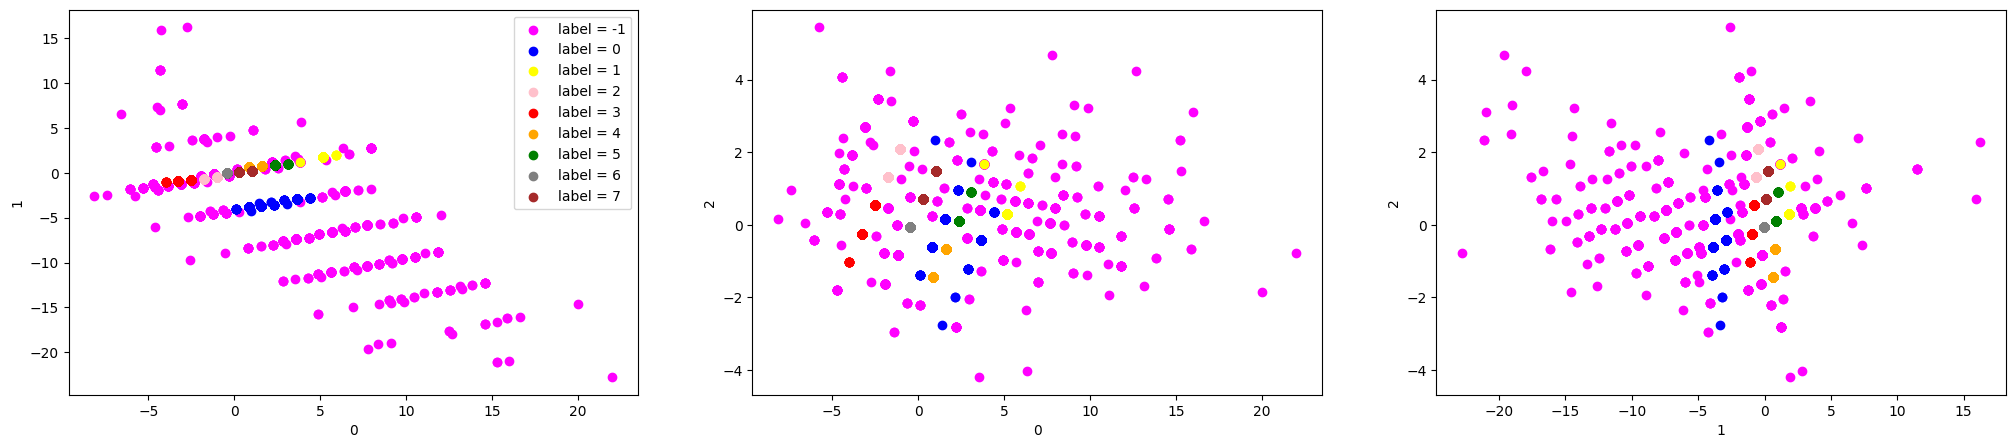

In [78]:
coords = combinaisons(3)
fig,axs = plt.subplots(1,len(coords),figsize=(25,5))
for clust in np.unique(hdb.labels_):
        for c,(i,j) in enumerate(coords):
            axs[c].scatter(data_list[clust][:,i],data_list[clust][:,j],color = ['blue','yellow','pink','red','orange','green','gray','brown','purple','magenta'][clust],label=f'label = {clust}')   
            axs[c].set_xlabel(i)
            axs[c].set_ylabel(j)
axs[0].legend()

### Let us show that one do not identify cluster with an SVD on the matrix containing all data, each individual is contenation of flatten trajectories of features

# UMAP on matrix containing all data, each individual is contenation of flatten trajectories of features

In [79]:
import umap

In [80]:
data = content_imgep['numpy_view']
print('data shape', data.shape)
data = norm_mean_std(data)

data shape (100000, 18)


In [81]:
reducer = umap.UMAP(n_components=6,metric="euclidean")
embedding = reducer.fit_transform(data)

In [19]:
dimension = 5
idx = [(i,j) for j in range(1,dimension) for i in range(j)]
print(idx)

[(0, 1), (0, 2), (1, 2), (0, 3), (1, 3), (2, 3), (0, 4), (1, 4), (2, 4), (3, 4)]


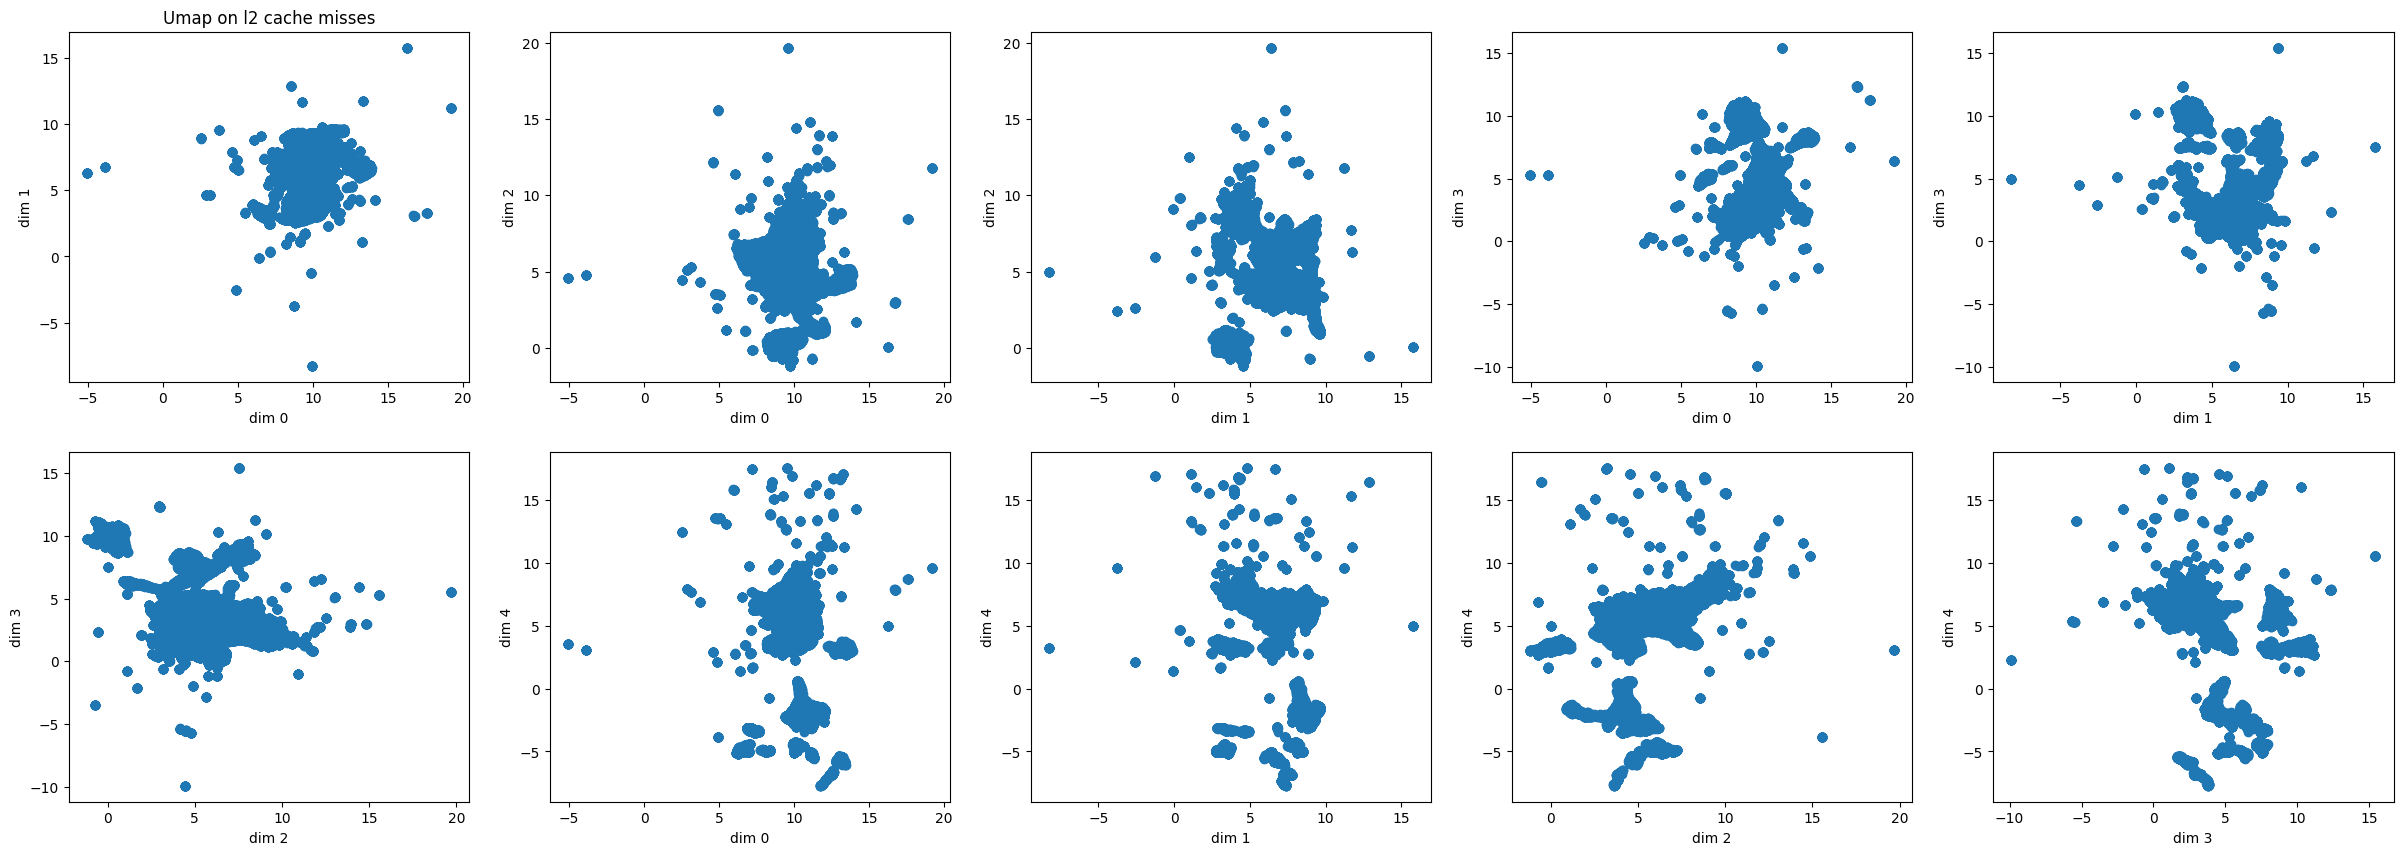

In [28]:
fig,axs=plt.subplots(2,5,figsize=(30,10))
for j in range(len(idx)):
    axs[j//5,j%5].scatter(embedding[:,idx[j][0]],embedding[:,idx[j][1]])
    axs[j//5,j%5].set_xlabel(f'dim {idx[j][0]}')
    axs[j//5,j%5].set_ylabel(f'dim {idx[j][1]}')
    if j==0:
        axs[j//5,j%5].set_title('Umap on l2 cache misses')
plt.show()

In [29]:
hdb = HDBSCAN(copy=True, min_cluster_size=2000)
hdb.fit(embedding)
print('hdb labels:',hdb.labels_)
print('labels',np.unique(hdb.labels_))

hdb labels: [ 3  3 -1 ...  0  0  3]
labels [-1  0  1  2  3  4  5  6]


In [30]:
data_list = {key:[] for key in np.unique(hdb.labels_)}   
for j in range(N):
        data_list[hdb.labels_[j]].append(embedding[j])

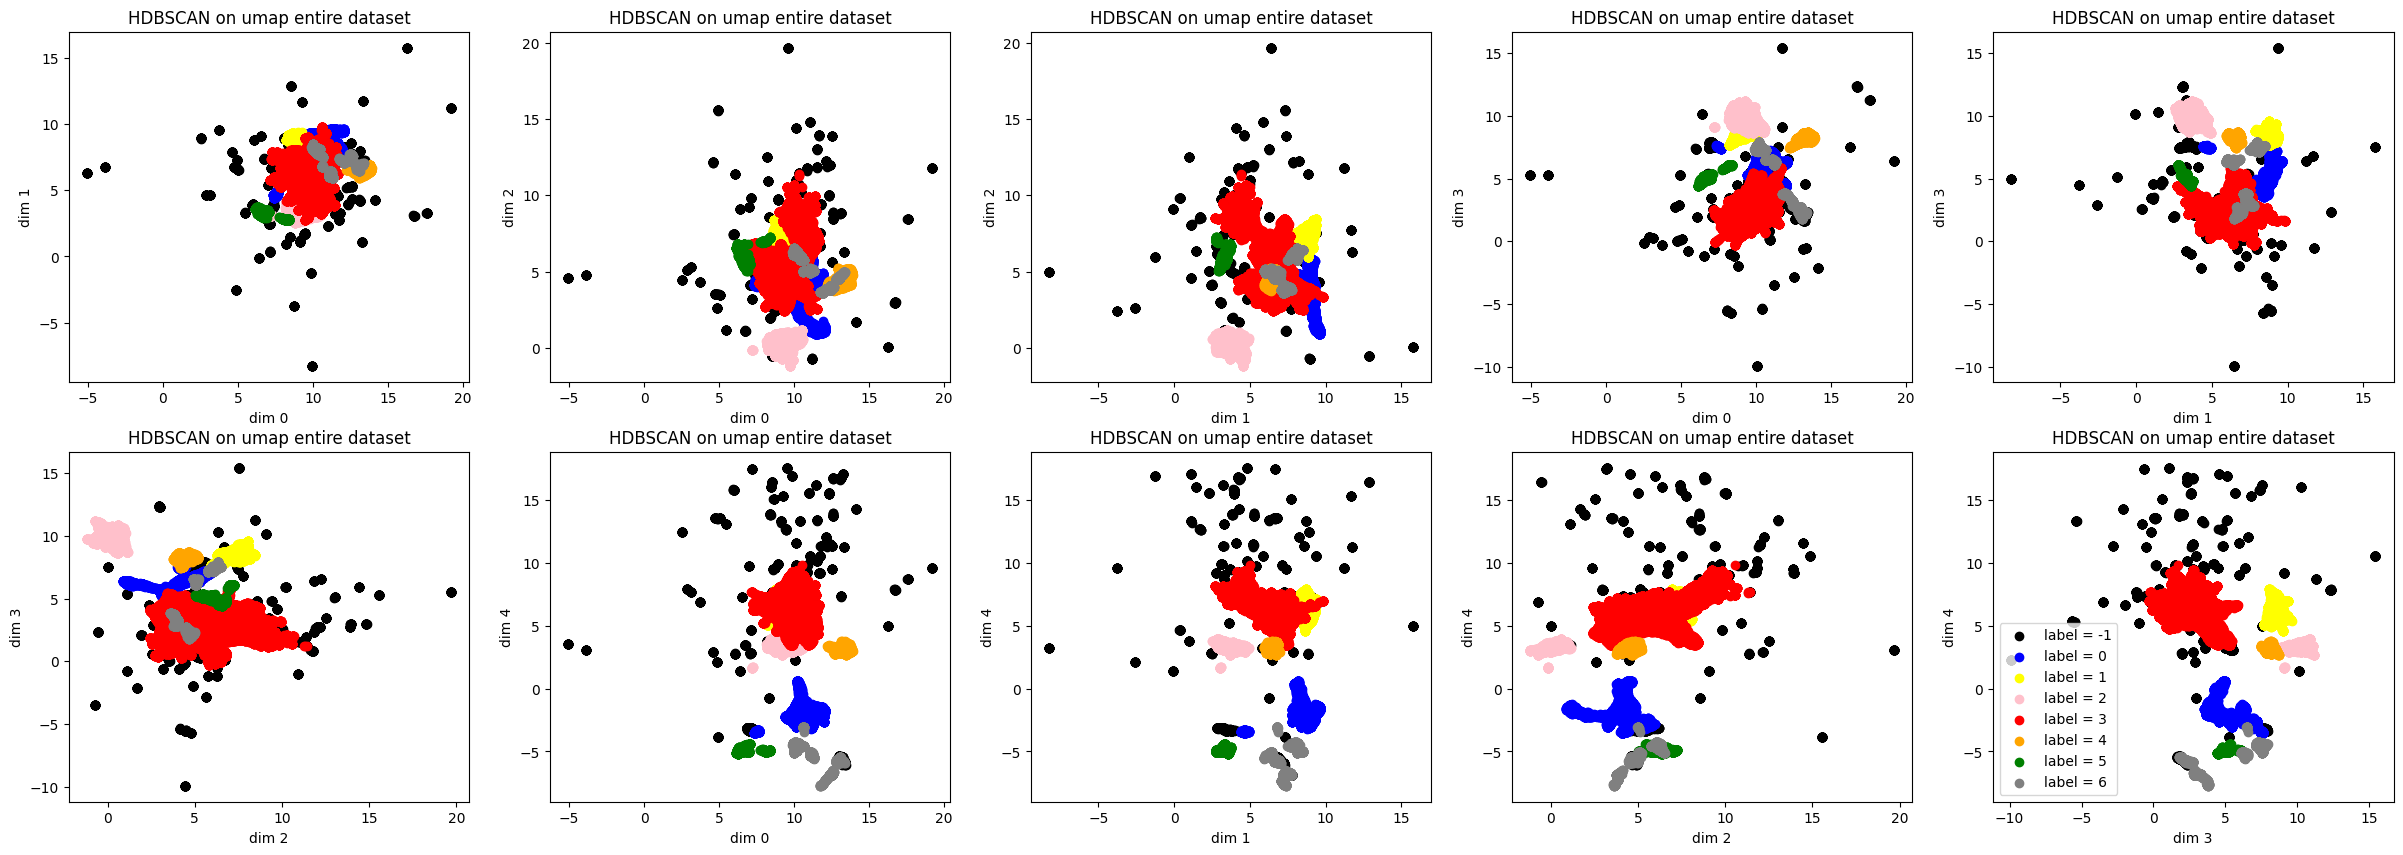

num elem label -1: 3836
num elem label 0: 14106
num elem label 1: 11325
num elem label 2: 11186
num elem label 3: 50061
num elem label 4: 3944
num elem label 5: 2330
num elem label 6: 3212


In [34]:
colors = ['black','blue','yellow','pink','red','orange','green','gray','brown','purple','magenta']
fig,axs=plt.subplots(2,5,figsize=(30,10))
for i in range(len(idx)):
    for j,key in enumerate(data_list):
        axs[i//5,i%5].scatter(np.array(data_list[key])[:,idx[i][0]],np.array(data_list[key])[:,idx[i][1]],color = colors[j],label=f'label = {key}')
        axs[i//5,i%5].set_title('HDBSCAN on umap entire dataset')
        axs[i//5,i%5].set_xlabel(f'dim {idx[i][0]}')
        axs[i//5,i%5].set_ylabel(f'dim {idx[i][1]}')
plt.legend()
plt.show()
for label in data_list:
    print(f'num elem label {label}: {len(data_list[label])}')

In [47]:
clusters_imgep = {key:{feature:[] for feature in content_imgep['memory_observation'].keys()} for key in np.unique(hdb.labels_)}   
for j in range(N):
        for feature in content_imgep['memory_observation']:
            clusters_imgep[hdb.labels_[j]][feature].append(content_imgep['memory_observation'][feature][j])
clusters_imgep = {key:{feature:np.array(clusters_imgep[key][feature]) for feature in clusters_imgep[key]} for key in clusters_imgep}

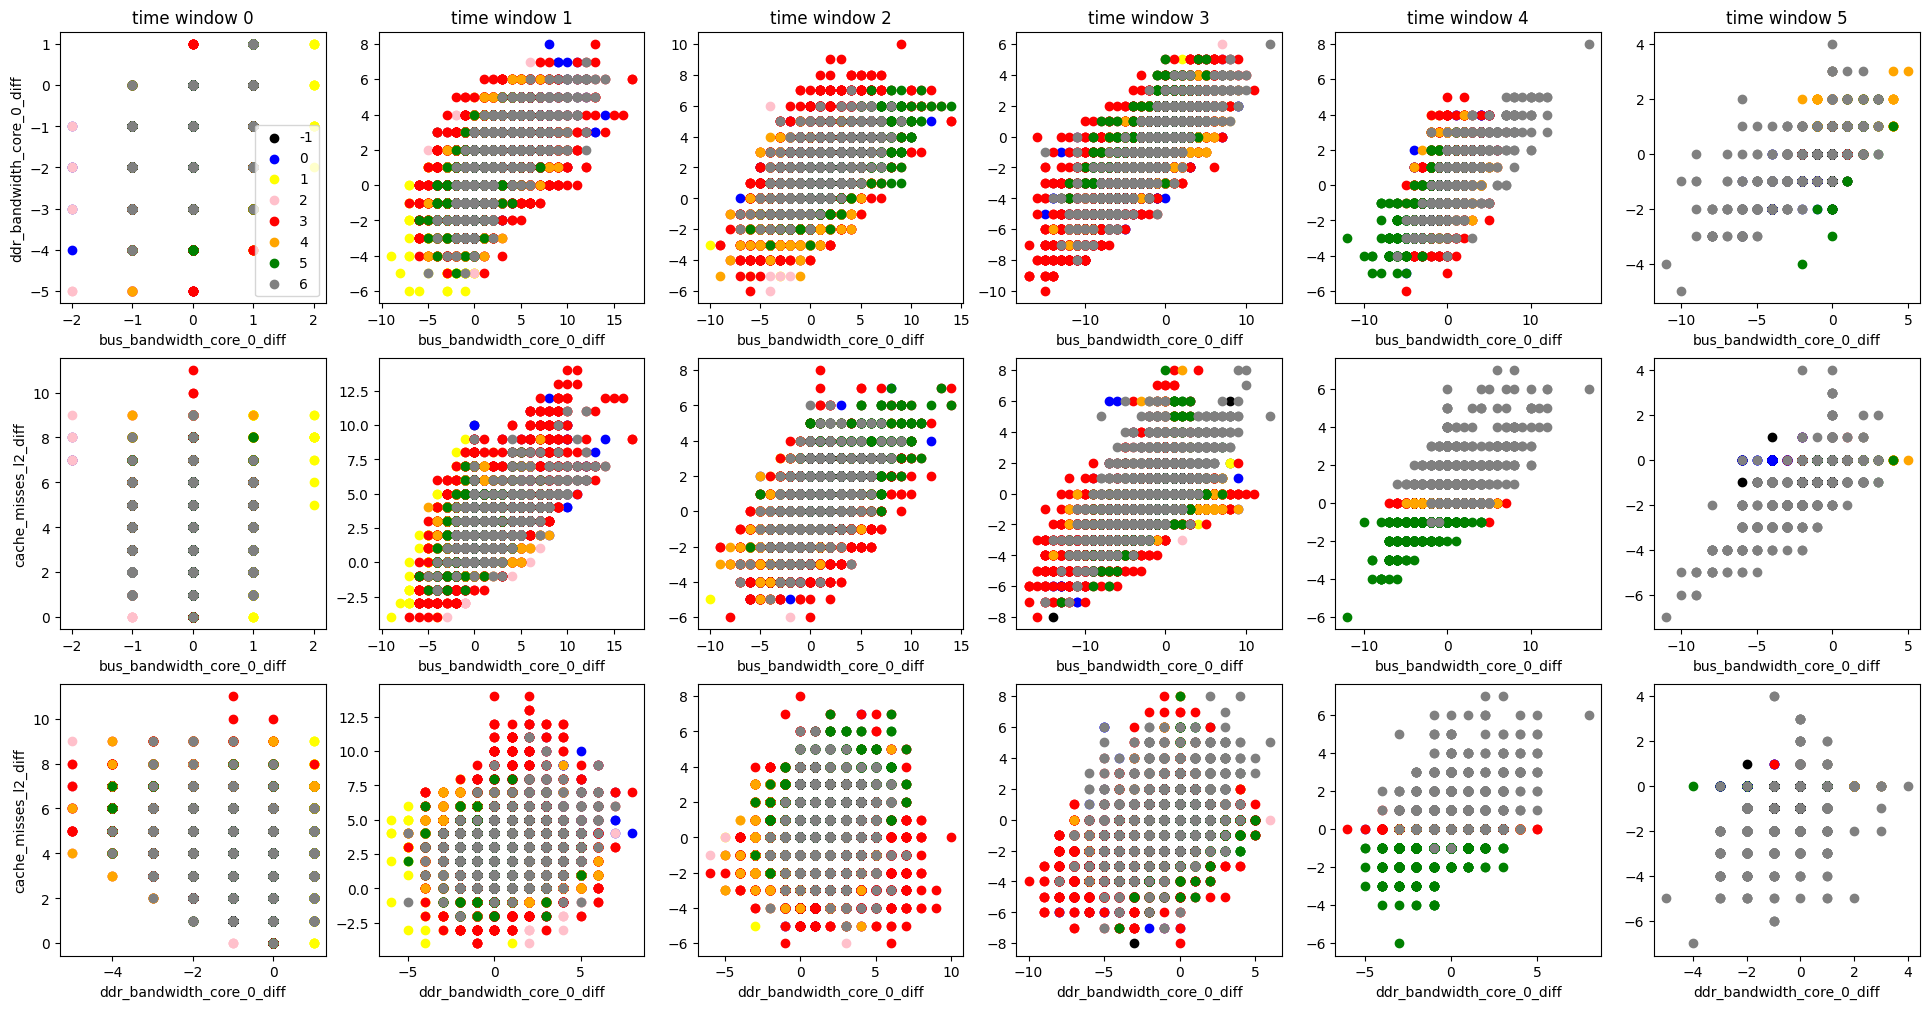

In [36]:
combins = combinaisons(3)
fig,axs = plt.subplots(len(combins),6,figsize=(24,12))
list_feature = ['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff']
colors = ['blue','yellow','pink','red','orange','green','gray','brown','purple','magenta','black']
for paire,(i,j) in enumerate(combins):
    for time in range(0,6):
        for clust in clusters_imgep:
            axs[paire,time].scatter(np.array(clusters_imgep[clust][list_feature[i]])[:,time],np.array(clusters_imgep[clust][list_feature[j]])[:,time],color = colors[clust],label=clust)
            axs[paire,time].set_xlabel(list_feature[i])
            if paire==0:
                axs[0,time].set_title(f'time window {time}')
    axs[paire,0].set_ylabel(list_feature[j])
axs[0,0].legend()

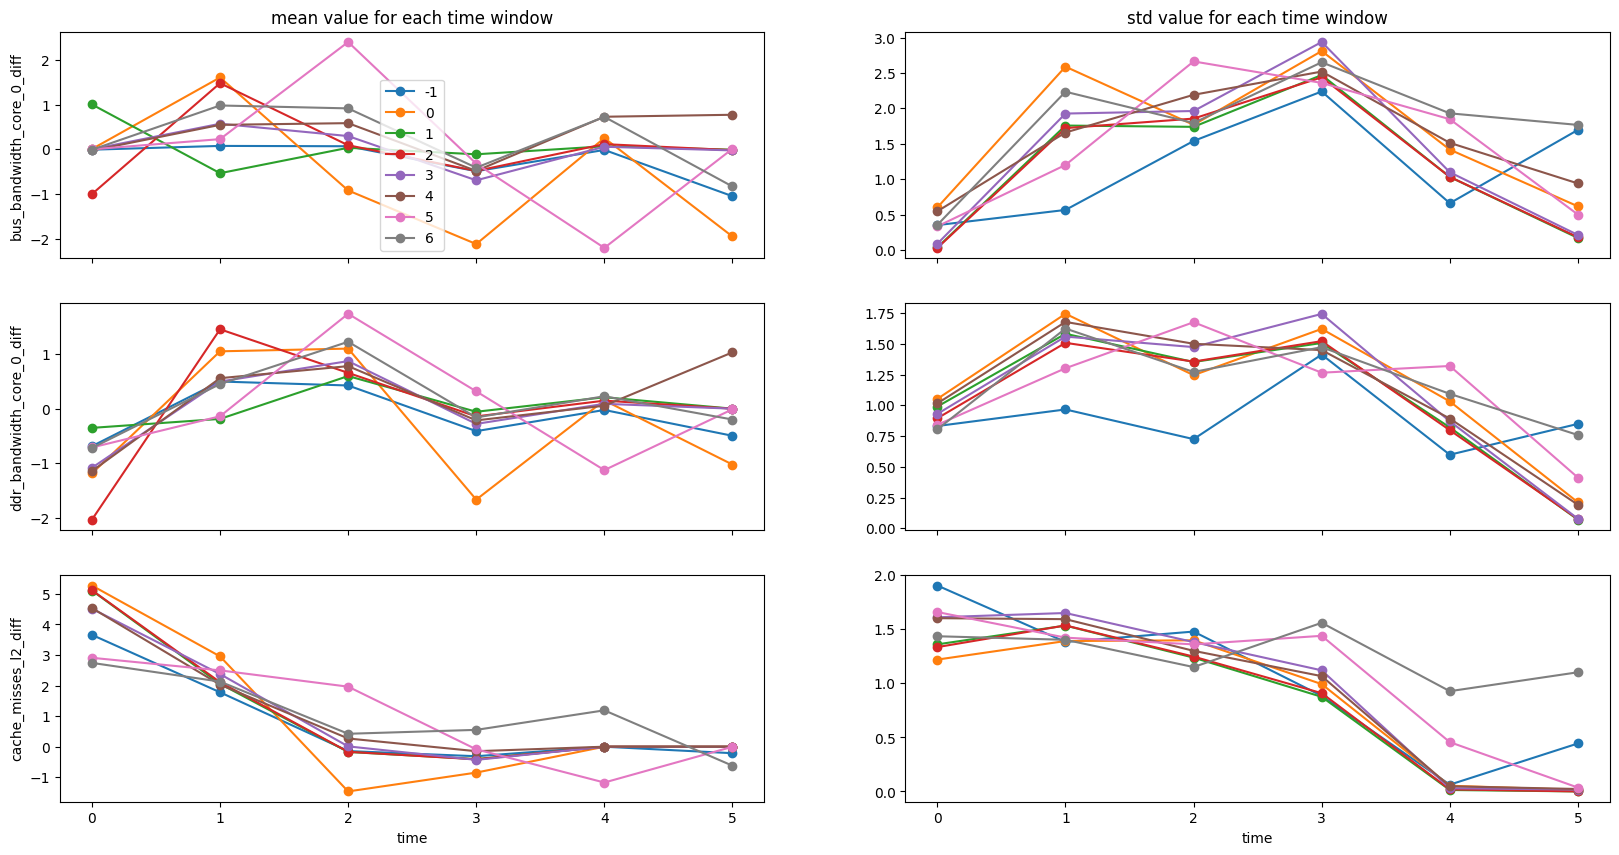

In [125]:
fig,axes = plt.subplots(3,2,figsize=(20,10),sharex=True)
for ligne,feature in enumerate(['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff']):
    for j in clusters_imgep:
        a = np.array(clusters_imgep[j][feature])
        axes[ligne,0].plot(a.mean(axis=0),'-o',label=j)
        axes[ligne,1].plot(a.std(axis=0),'-o',label=j)
    axes[ligne,0].set_ylabel(feature)
axes[0,0].legend()
axes[0,0].set_title('mean value for each time window')
axes[0,1].set_title('std value for each time window')
axes[2,0].set_xlabel('time')
axes[2,1].set_xlabel('time')
plt.show()


In [107]:
import pandas as pd

dic_cluster_2_corr = {}
feature_list = ['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff']
for cluster in clusters_imgep:
    list_df = []
    if cluster!=-1:
        for time in range(6):
            df = pd.DataFrame([])
            for feature in feature_list:
                if feature =='time_core0_diff':
                    pass
                     #df[feature] = np.array(clusters_imgep[cluster]['time_core0_core1']) - np.array(clusters_imgep[cluster]['time_core0_iso'])
                else:
                    df[feature] = np.array(clusters_imgep[cluster][feature])[:,time]
            list_df.append(df.corr())
        dic_cluster_2_corr[cluster] = list_df
#np.array(clusters_imgep[hdb.labels_[j]]['bus_bandwidth_core_0_diff']).shape

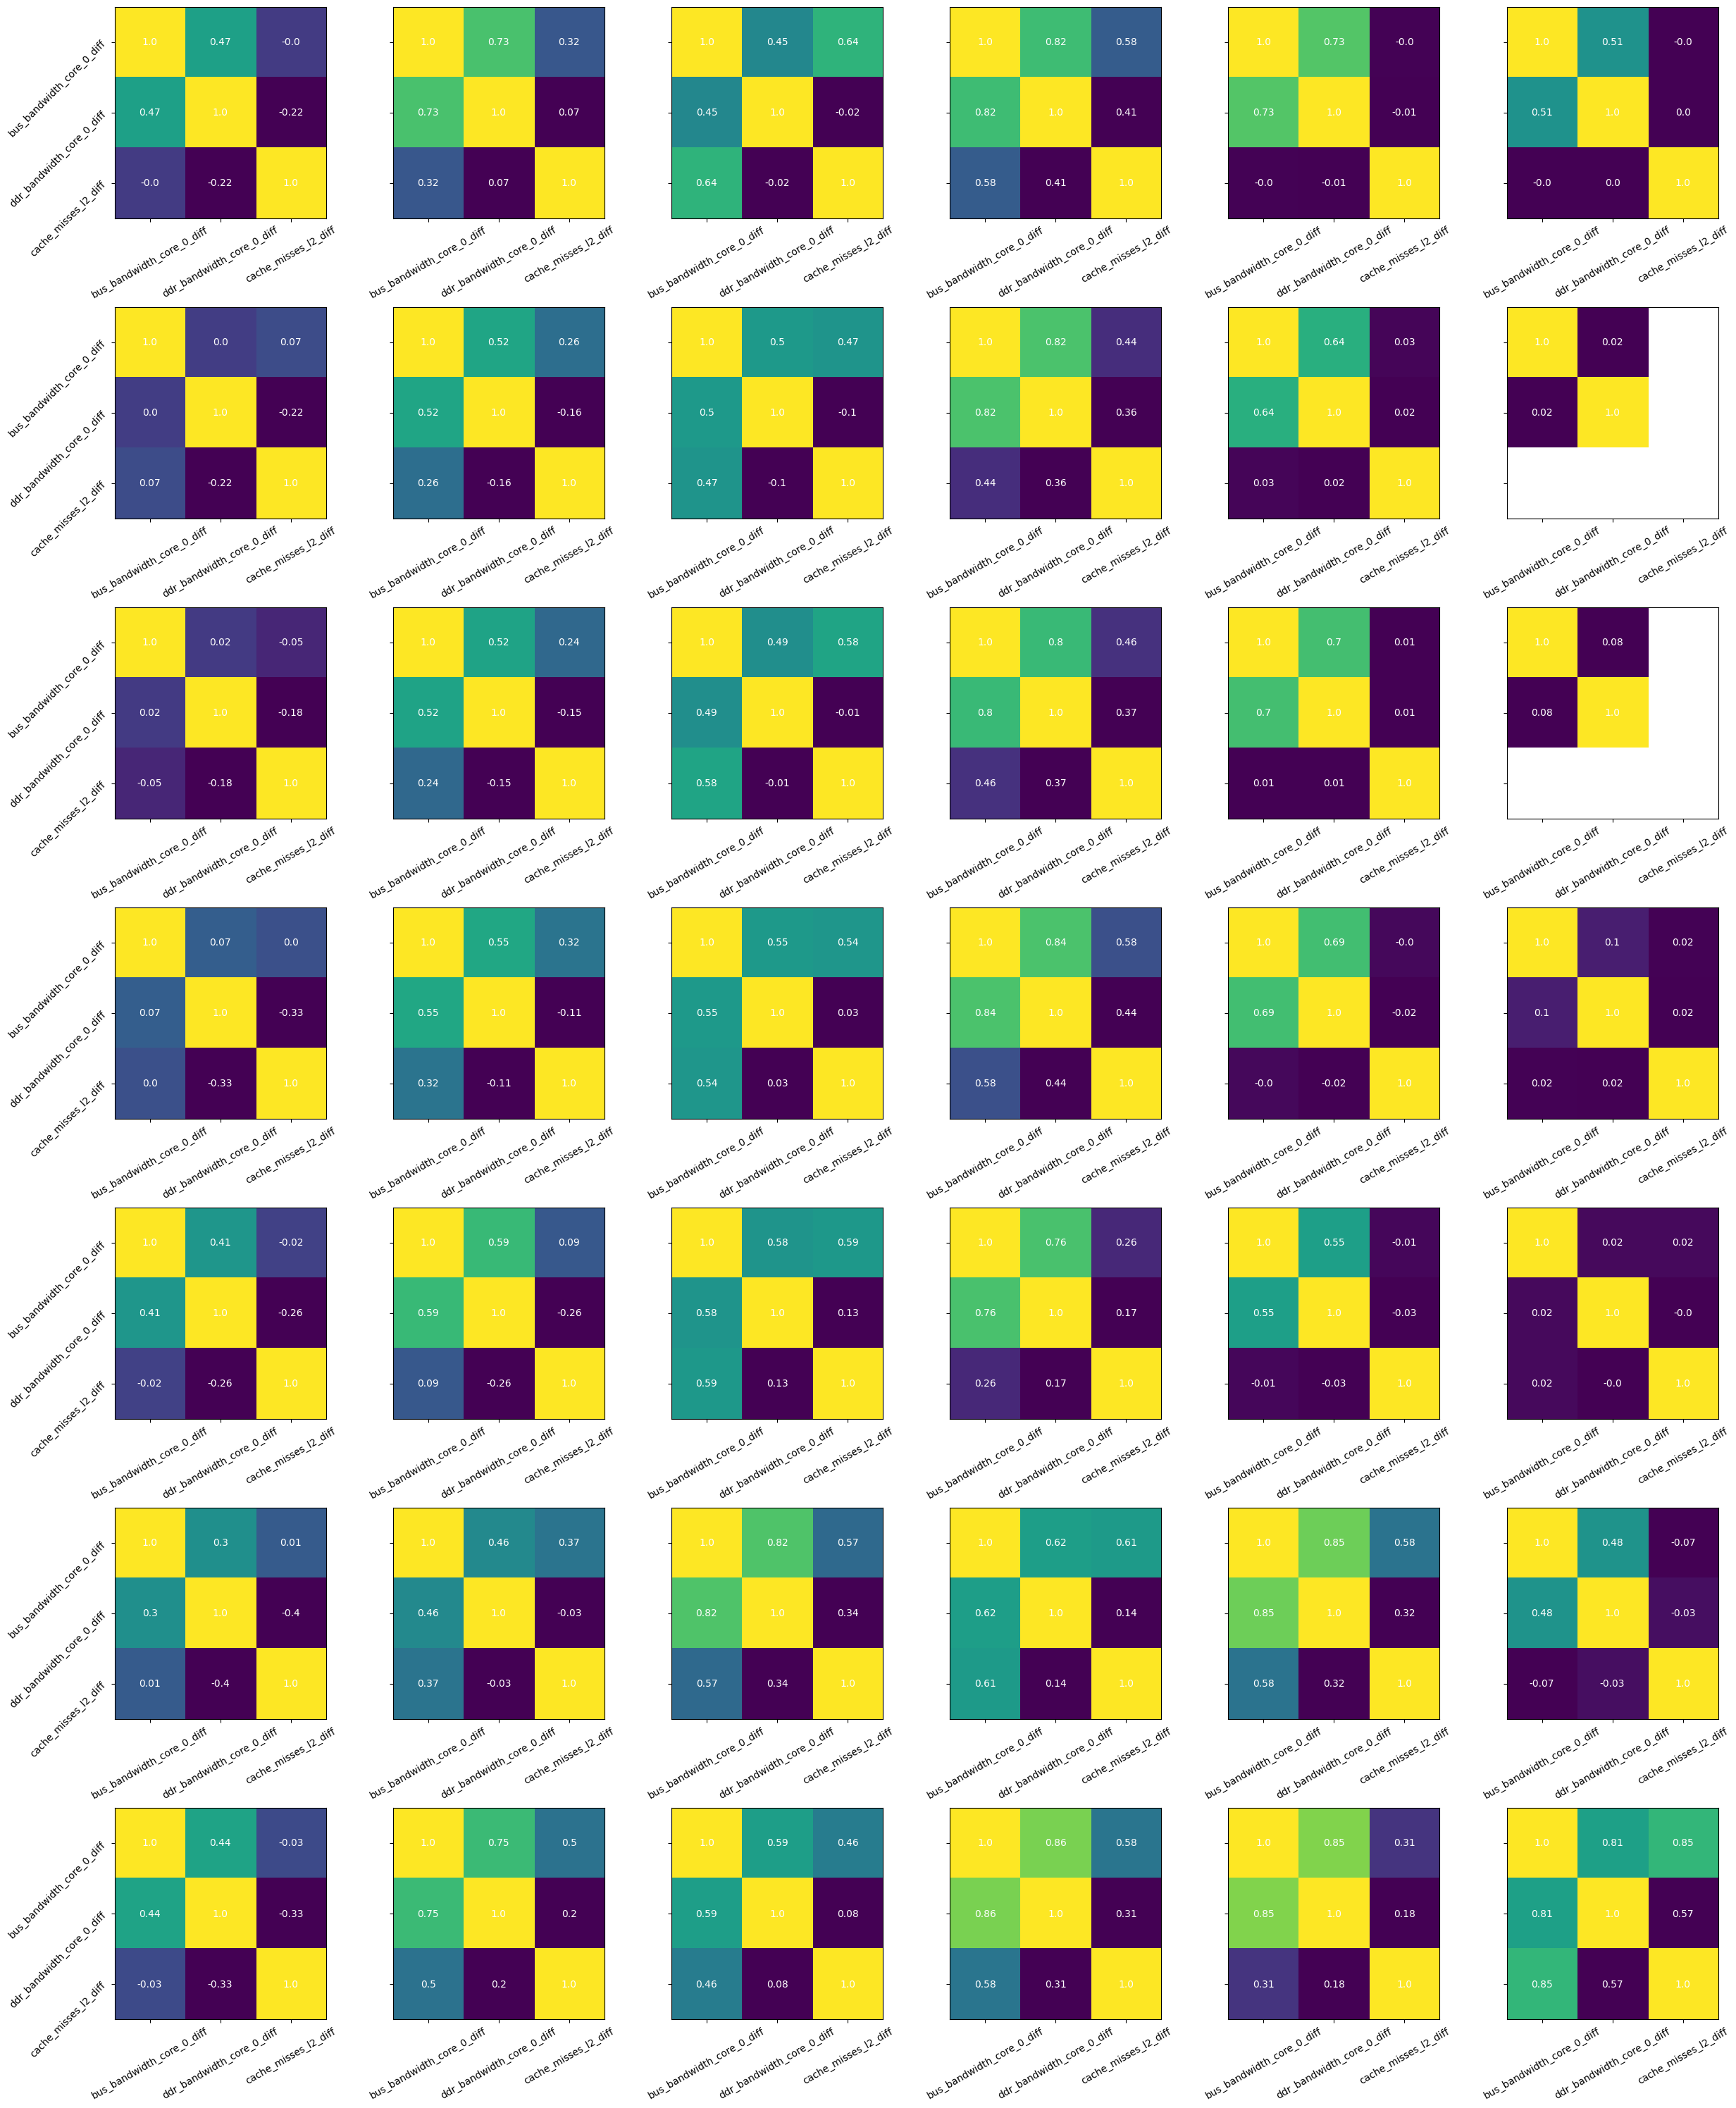

In [114]:
fig, axs = plt.subplots(len(clusters_imgep)-1,6, figsize=(25, 30),sharey=True)#,sharex=False)
for time in range(6):
    for clust in clusters_imgep:
        if clust!=-1:
            # Show all ticks and label them with the respective list entries
            axs[clust,time].imshow(dic_cluster_2_corr[clust][time])
            axs[clust,time].set_xticks(range(len(feature_list)), labels=feature_list,rotation=30)
            axs[clust,time].set_yticks(range(len(feature_list)), labels=feature_list,rotation=45)
            
            # Loop over data dimensions and create text annotations.
            for i in range(len(feature_list)):
                for j in range(len(feature_list)):
                    text = axs[clust,time].text(j, i, dic_cluster_2_corr[clust][time].values.round(2)[i, j],ha="center", va="center", color="w")
fig.tight_layout()
plt.show()

In [77]:
content_imgep['memory_observation'].keys()

dict_keys(['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff', 'bus_bandwidth_core_0_iso', 'bus_bandwidth_core_0_core1', 'ddr_bandwidth_core_0_iso', 'ddr_bandwidth_core_0_core1', 'time_core0_iso', 'time_core0_core1'])

In [128]:
allongement_mean = {}
list_features = ['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff','time_core0_diff']
for feature in list_features:
    allongement_mean[feature] = {}
    for cluster in clusters_imgep:
        if feature =='time_core0_diff':
            allongement = np.array(clusters_imgep[cluster]['time_core0_core1']) - np.array(clusters_imgep[cluster]['time_core0_iso'])
        else:
            allongement = np.array(clusters_imgep[cluster][feature])
        #break
        if feature!='time_core0_diff':
            mean_allongement = np.mean(allongement,axis=0)
        else:
            mean_allongement = np.mean(allongement)# a revoir, la matrice est trop grande et on perd de l'information
        allongement_mean[feature][cluster] = mean_allongement

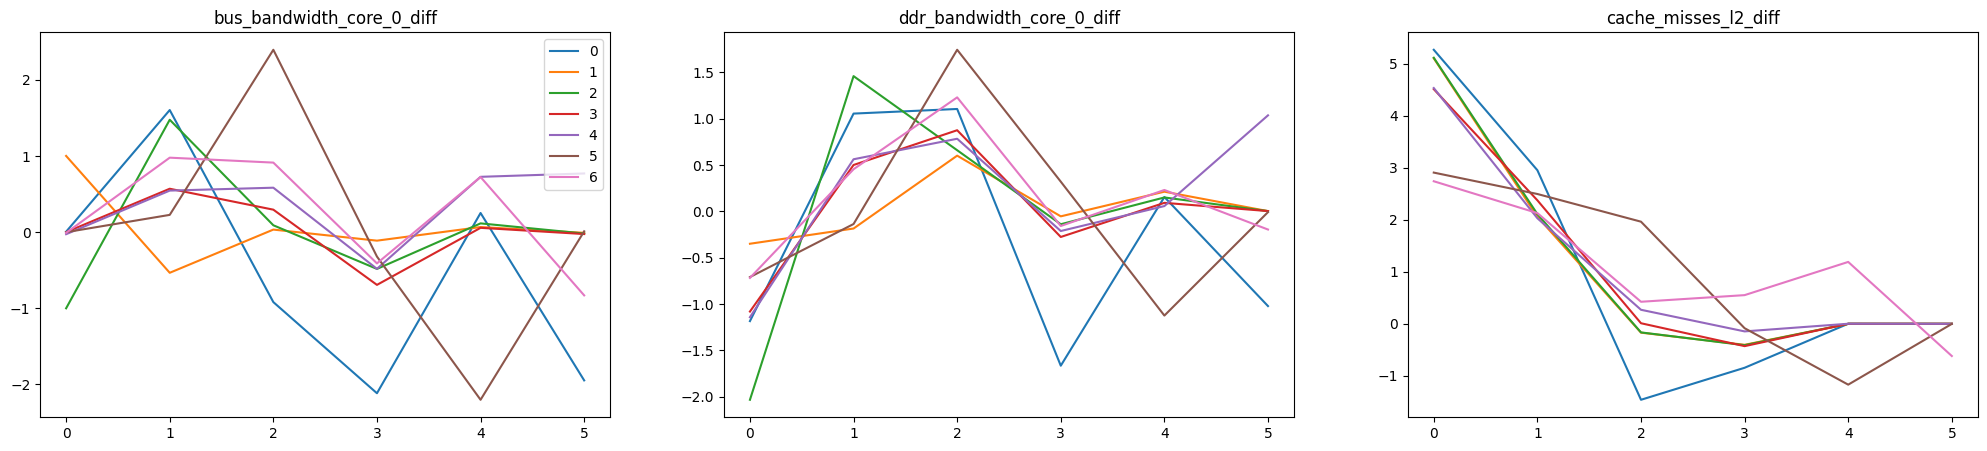

In [136]:
fig,axes = plt.subplots(1,3,figsize =(25,5))
for i,feature in enumerate(['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff']):
    for clust in clusters_imgep:
        if clust!=-1:
            axes[i].plot(allongement_mean[feature][clust],label=clust)
        
        axes[i].set_title(feature)
axes[0].legend()
plt.show()

## Attempt to identify clusters with Kmeans on untouched simulator data
--> sklearn website to
"Silhouette analysis can be used to study the separation distance between the resulting clusters. The silhouette plot displays a measure of how close each point in one cluster is to points in the neighboring clusters and thus provides a way to assess parameters like number of clusters visually. This measure has a range of [-1, 1].

Silhouette coefficients (as these values are referred to as) near +1 indicate that the sample is far away from the neighboring clusters. A value of 0 indicates that the sample is on or very close to the decision boundary between two neighboring clusters and negative values indicate that those samples might have been assigned to the wrong cluster."

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
for n_clusters in range(2,6):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit(data)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(data, labels)
    print(
    "For n_clusters =",
    n_clusters,
    "The average silhouette_score is :",
    silhouette_avg,
    )

### --> the values indicate pool clusters as they are far from 1.

# essayer critere elbow pour montrer qu'on ne tire pas grand chose de clusters
# Visualiser clusters